# Quantum Full Adder

Construct a reversible full adder with CNOT and Toffoli gates. Inputs are q0 = A, q1 = B, and q2 = carry-in; outputs are q3 = sum and q4 = carry-out. The circuit restores the input B after using it temporarily.

Run the cells from top to bottom in a fresh Python kernel. See the [repository README](../README.md) for environment setup.

**Bit ordering:** Qiskit displays bit strings with the highest-index bit on the left and bit 0 on the right. Ideal simulator results are used here; shot counts can fluctuate when several outcomes have nonzero probability.

## Adding a fixed input: 1 + 1 + 1

The sum is A XOR B XOR carry-in. Carry-out is (A AND B) XOR ((A XOR B) AND carry-in). This example measures only the outputs, with strings ordered `carry sum`; expect `11`.

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2, 2, 2, 2))


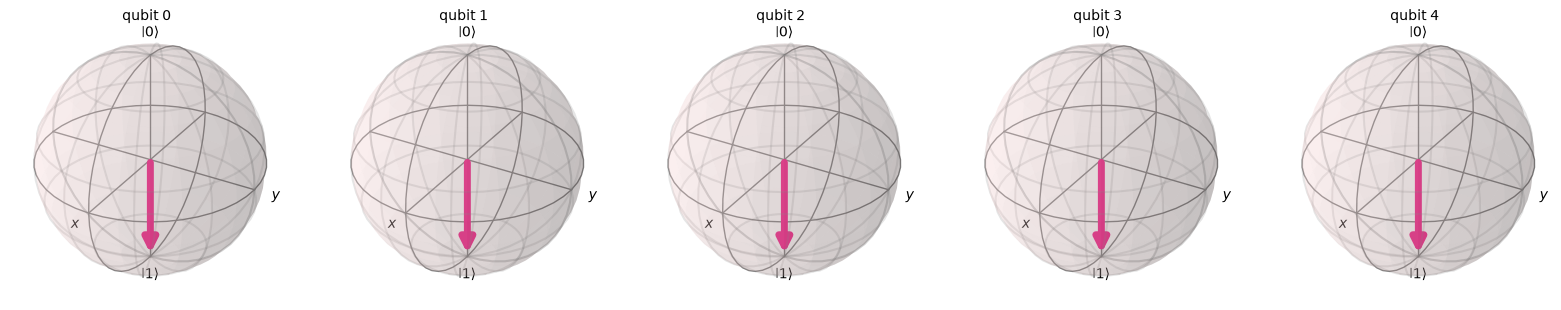

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1.]
{np.str_('11111'): np.float64(1.0)}
{'11': 1000}


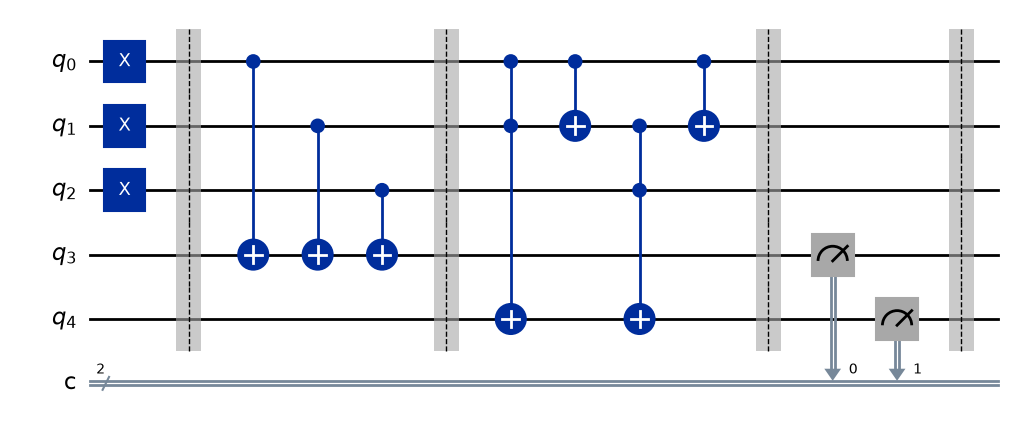

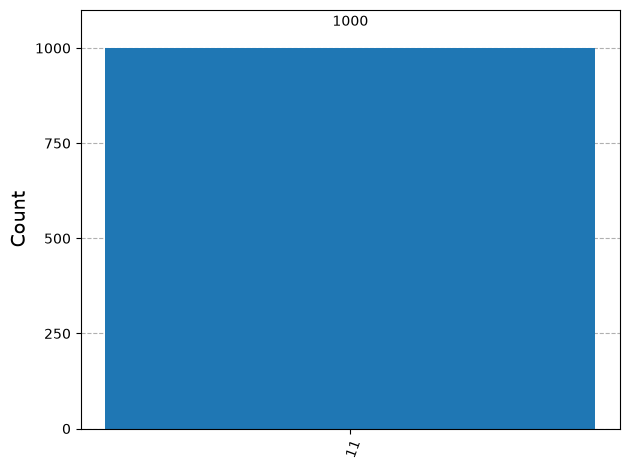

In [1]:
from qiskit import QuantumCircuit, transpile 
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import Aer


qc = QuantumCircuit(5 , 2)

qc.x(0) # A
qc.x(1) # B
qc.x(2) # C
qc.barrier()

qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(2, 3)
qc.barrier()


qc.ccx(0 , 1, 4)
qc.cx(0 , 1)
qc.ccx(1 , 2 , 4)
qc.cx(0 , 1)
qc.barrier()


vtr = Statevector.from_instruction(qc)
print(vtr)
display(plot_bloch_multivector(vtr))
print(vtr.probabilities())
print(vtr.probabilities_dict())

qc.measure(3 , 0)
qc.measure(4 , 1)
qc.barrier()

sm = Aer.get_backend("qasm_simulator")
tc = transpile(qc, sm)

rs = sm.run(tc, shots = 1000).result()
counts = rs.get_counts(qc)

print(counts)
display(qc.draw("mpl"))
display(plot_histogram(counts))

## All input combinations in superposition

Hadamard gates prepare all eight inputs with equal amplitudes. All five qubits are measured, so each string is ordered `carry sum carry-in B A`. Each shot reveals one valid input/output combination.

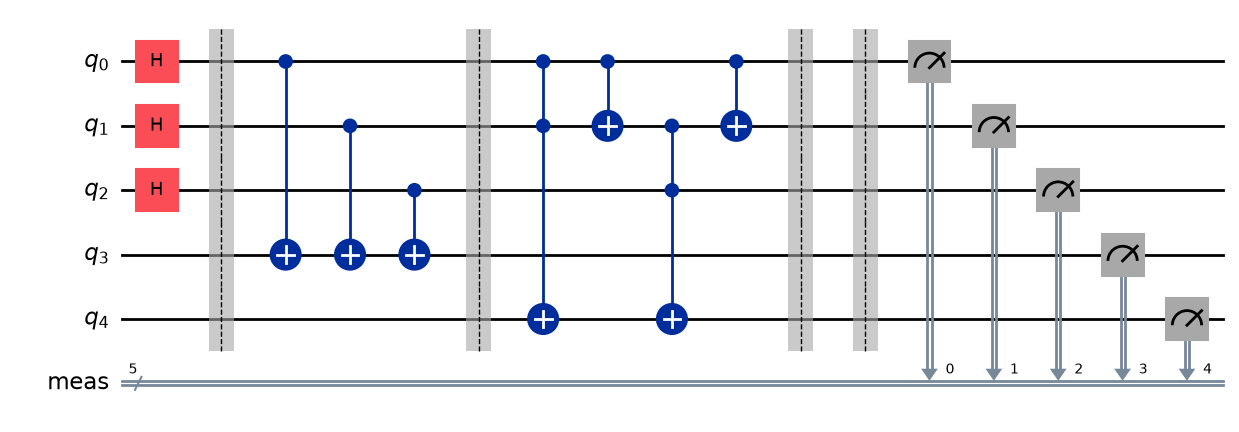

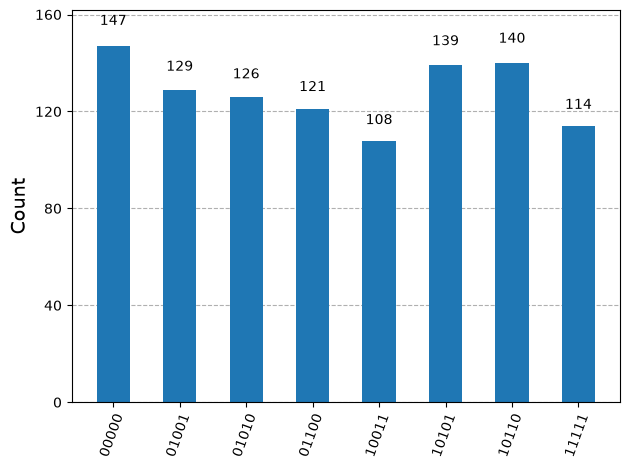

{'10110': 140, '11111': 114, '01001': 129, '01010': 126, '00000': 147, '10011': 108, '01100': 121, '10101': 139}


In [2]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


# Create circuit: 5 qubits; measure_all() later adds 5 classical bits
# q0 = A
# q1 = B
# q2 = Cin
# q3 = Sum
# q4 = Carry

qc = QuantumCircuit(5)


# Put input qubits q0, q1, q2 in superposition
# to generate all input combinations

qc.h(0)
qc.h(1)
qc.h(2)

qc.barrier()


# -------------------------------------------------
# SUM
# q3 = A XOR B XOR Cin
# -------------------------------------------------

qc.cx(0, 3)      # q3 = A
qc.cx(1, 3)      # q3 = A XOR B
qc.cx(2, 3)      # q3 = A XOR B XOR Cin

qc.barrier()


# -------------------------------------------------
# CARRY
# q4 = Carry
# -------------------------------------------------

qc.ccx(0, 1, 4)      # Carry from A AND B

qc.cx(0, 1)           # temporary: A XOR B in q1

qc.ccx(1, 2, 4)      # Carry from (A XOR B) AND Cin

qc.cx(0, 1)           # restore original B

qc.barrier()


# -------------------------------------------------
# Measure inputs, Sum, and Carry
# -------------------------------------------------

qc.measure_all()

# -------------------------------------------------
# Draw circuit
# -------------------------------------------------

display(qc.draw(output="mpl"))


# -------------------------------------------------
# Run simulation
# -------------------------------------------------

simulator = Aer.get_backend("qasm_simulator")

compiled_circuit = transpile(qc, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()


# -------------------------------------------------
# Plot results
# -------------------------------------------------

display(plot_histogram(counts))

print(counts)
